In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Section 1

In [45]:
flat_source, flat_target, inv, hl, f1, L, f2, da, a_max, w = np.loadtxt('data2mc/input.csv', delimiter = ',')
source_text = "flat" if flat_source else "cylindrical"
target_text = "flat" if flat_target else "cylindrical"
inverted_text = "inverted" if inv else "not inverted"
print(f"{source_text} source -> {target_text} target, {inverted_text}")
print(f"half-length = {hl}, f1 = {f1}, L = {L}, f2 = {f2}, da = {da}, a_max = {a_max}, w = {w}")

flat source -> flat target, not inverted
half-length = 0.001, f1 = 1.0, L = 4.0, f2 = 2.0, da = 1e-06, a_max = 90.0, w = 1.0


# Plot

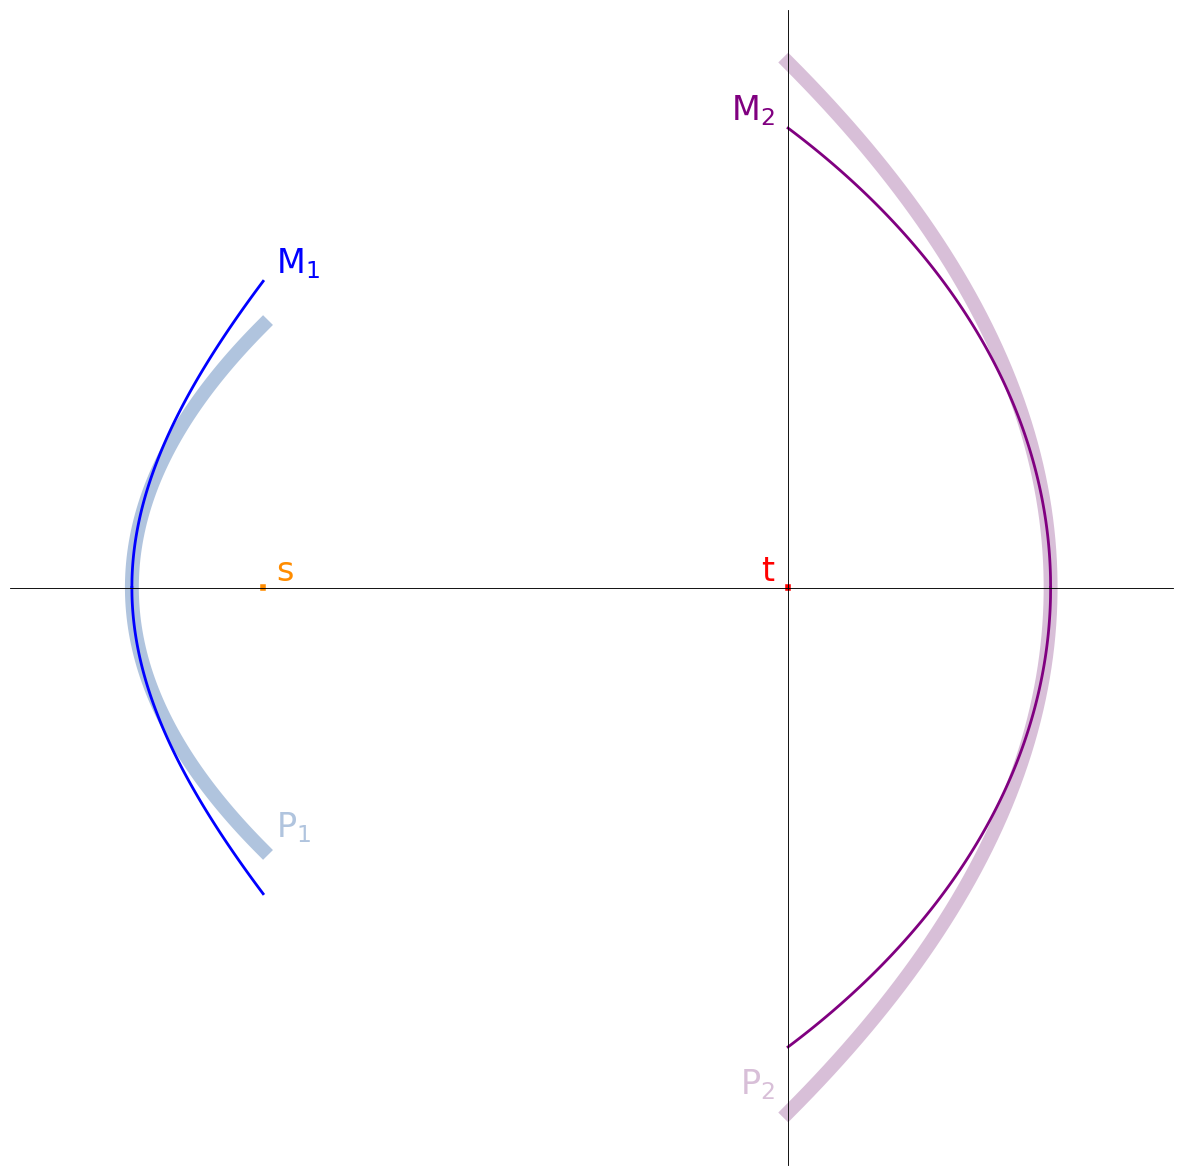

In [46]:
fig, ax = plt.subplots(1, figsize = (15, 15))
ax.spines['left'].set_position('zero')
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_position('zero')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['right'].set_position('zero')
ax.spines['right'].set_linewidth(0.5)
ax.spines['top'].set_position('zero')
ax.spines['top'].set_linewidth(0.5)
ax.set_xticks([])
ax.set_yticks([])

adj = 0.1

Y1 = np.linspace(-2 * f1, 2 * f1, 100)
X1 = 1 / (4 * f1) * (Y1 ** 2) - L - f1
ax.plot(X1, Y1, linewidth = 10, c = 'lightsteelblue')
ax.text(X1[-1] + adj, Y1[1], ha = 'left', va = 'bottom', s = r"$\text{P}_1$", fontsize = 24, color = 'lightsteelblue')
Y2 = np.linspace(-2 * f2, 2 * f2, 100)
X2 = -1 / (4 * f2) * (Y2 ** 2) + f2
ax.plot(X2, Y2, linewidth = 10, c = 'thistle')
ax.text(X2[-1] - adj, Y2[1], ha = 'right', va = 'bottom', s = r"$\text{P}_2$", fontsize = 24, color = 'thistle')

mirror1a = np.loadtxt('data2mc/mirror1a.csv', delimiter = ',')
mirror1b = np.loadtxt('data2mc/mirror1b.csv', delimiter = ',')
mirror2a = np.loadtxt('data2mc/mirror2a.csv', delimiter = ',')
mirror2b = np.loadtxt('data2mc/mirror2b.csv', delimiter = ',')
ax.plot(mirror1a[:, 0], mirror1a[:, 1], linewidth = 2, c = 'blue', label = r"$\text{M}_1$")
ax.plot(mirror1b[:, 0], mirror1b[:, 1], linewidth = 2, c = 'blue')
ax.text(mirror1a[-1, 0] + adj, mirror1a[-1, 1], ha = 'left', va = 'bottom', s = r"$\text{M}_1$", fontsize = 24, color = 'blue')
ax.plot(mirror2a[:, 0], mirror2a[:, 1], linewidth = 2, c = 'purple', label = r"$\text{M}_2$")
ax.plot(mirror2b[:, 0], mirror2b[:, 1], linewidth = 2, c = 'purple')
ax.text(mirror2a[-1, 0] - adj, mirror2a[-1, 1], ha = 'right', va = 'bottom', s = r"$\text{M}_2$", fontsize = 24, color = 'purple')

plt.plot([-L, -L], [-hl, hl], linewidth = 4, color = 'darkorange', label = 'source')
ax.text(-L + adj, 0, ha = 'left', va = 'bottom', s = r"$\text{s}$", fontsize = 24, color = 'darkorange')
plt.plot([0, 0], [-hl * w, hl * w], linewidth = 4, color = 'red', label = 'target')
ax.text(0 - adj, 0, ha = 'right', va = 'bottom', s = r"$\text{t}$", fontsize = 24, color = 'red')

plt.axis('equal')
plt.show()

# Caustics

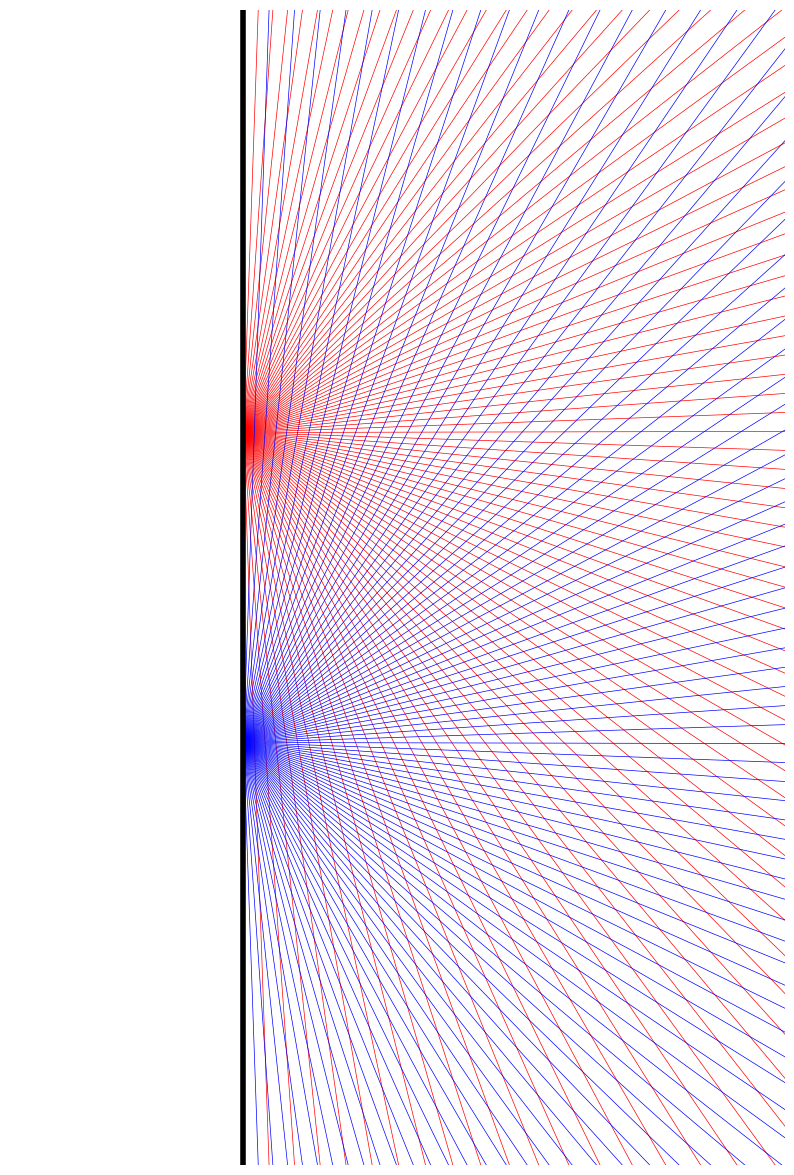

In [ ]:
fig, ax = plt.subplots(1, figsize = (15, 15))
# fig, ax = plt.subplots(1, figsize = (10, 15))
extreme1 = np.loadtxt('data2mc/extreme1.csv', delimiter = ',')
extreme2 = np.loadtxt('data2mc/extreme2.csv', delimiter = ',')
for row in extreme1: ax.plot([row[0], row[2]], [row[1], row[3]], linewidth = 0.5, c = 'red')
for row in extreme2: ax.plot([row[0], row[2]], [row[1], row[3]], linewidth = 0.5, c = 'blue')
# if flat_source and flat_target: plt.plot([0, 0], [-hl, hl], linewidth = 4, color = 'black', label = 'target')
# elif not flat_source and flat_target: plt.plot([0, 0], [-hl, hl], linewidth = 4, color = 'black', label = 'target')
plt.axis('equal')
zoom = hl * 2.5
plt.axis([-zoom, zoom, -zoom, zoom])
# plt.axis([-zoom + hl, zoom + hl, -zoom, zoom])
# plt.plot([0, 0], [-hl * 5, hl * 5], linewidth = 4, color = 'black', label = 'target')
plt.axis('off')
plt.show()

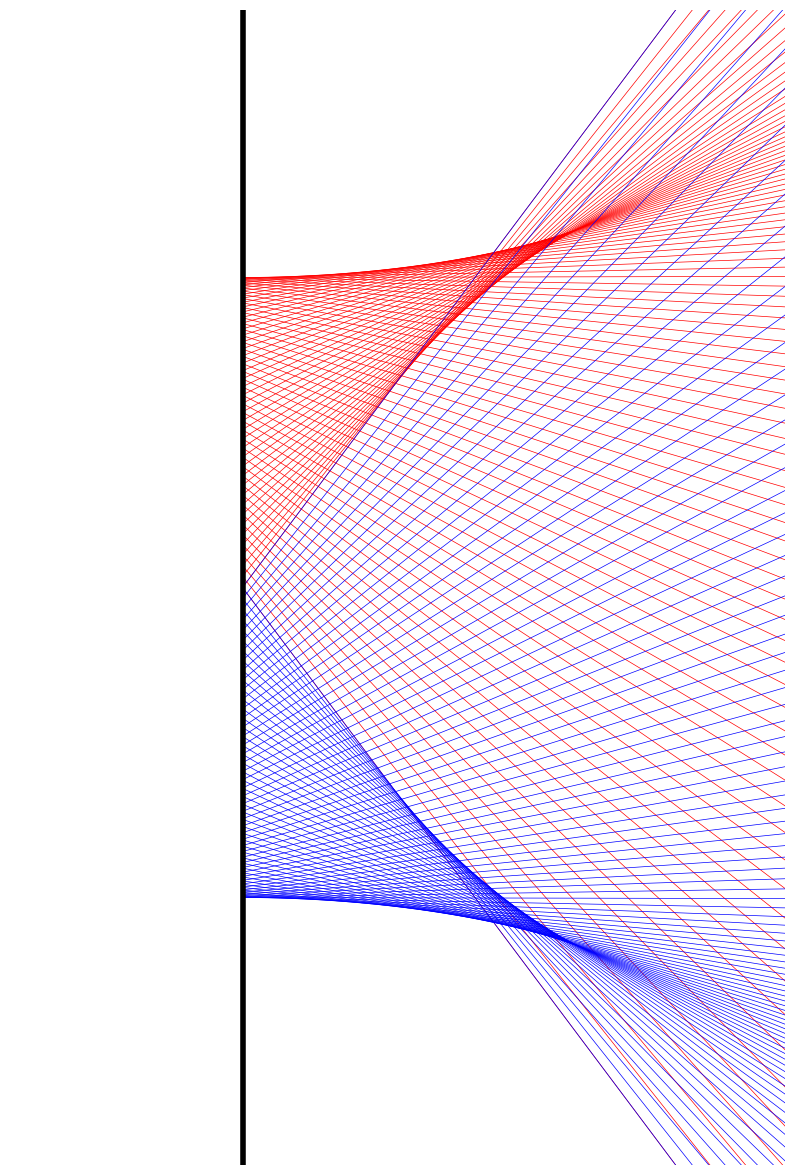

In [ ]:
fig, ax = plt.subplots(1, figsize = (15, 15))
# fig, ax = plt.subplots(1, figsize = (10, 15))
extrdiff1 = np.loadtxt('datapara/extreme1.csv', delimiter = ',')
extrdiff2 = np.loadtxt('datapara/extreme2.csv', delimiter = ',')
for row in extrdiff1: ax.plot([row[0], row[2]], [row[1], row[3]], linewidth = 0.5, c = 'red')
for row in extrdiff2: ax.plot([row[0], row[2]], [row[1], row[3]], linewidth = 0.5, c = 'blue')
# if flat_source and flat_target: plt.plot([0, 0], [-hl, hl], linewidth = 4, color = 'black', label = 'target')
# elif flat_source and not flat_target: plt.gca().add_patch(plt.Circle((0, 0), hl / np.pi, color = 'lightgrey', label = 'target'))
# elif not flat_source and flat_target: plt.plot([0, 0], [-hl, hl], linewidth = 4, color = 'black', label = 'target')
# elif not flat_source and not flat_target: plt.gca().add_patch(plt.Circle((0, 0), hl, color = 'lightgrey', label = 'target'))
plt.axis('equal')
zoom = hl * 2.5
plt.axis([-zoom, zoom, -zoom, zoom])
# plt.axis([-zoom + hl, zoom + hl, -zoom, zoom])
# plt.plot([0, 0], [-hl * 5, hl * 5], linewidth = 4, color = 'black', label = 'target')
plt.axis('off')
plt.show()

# Phase

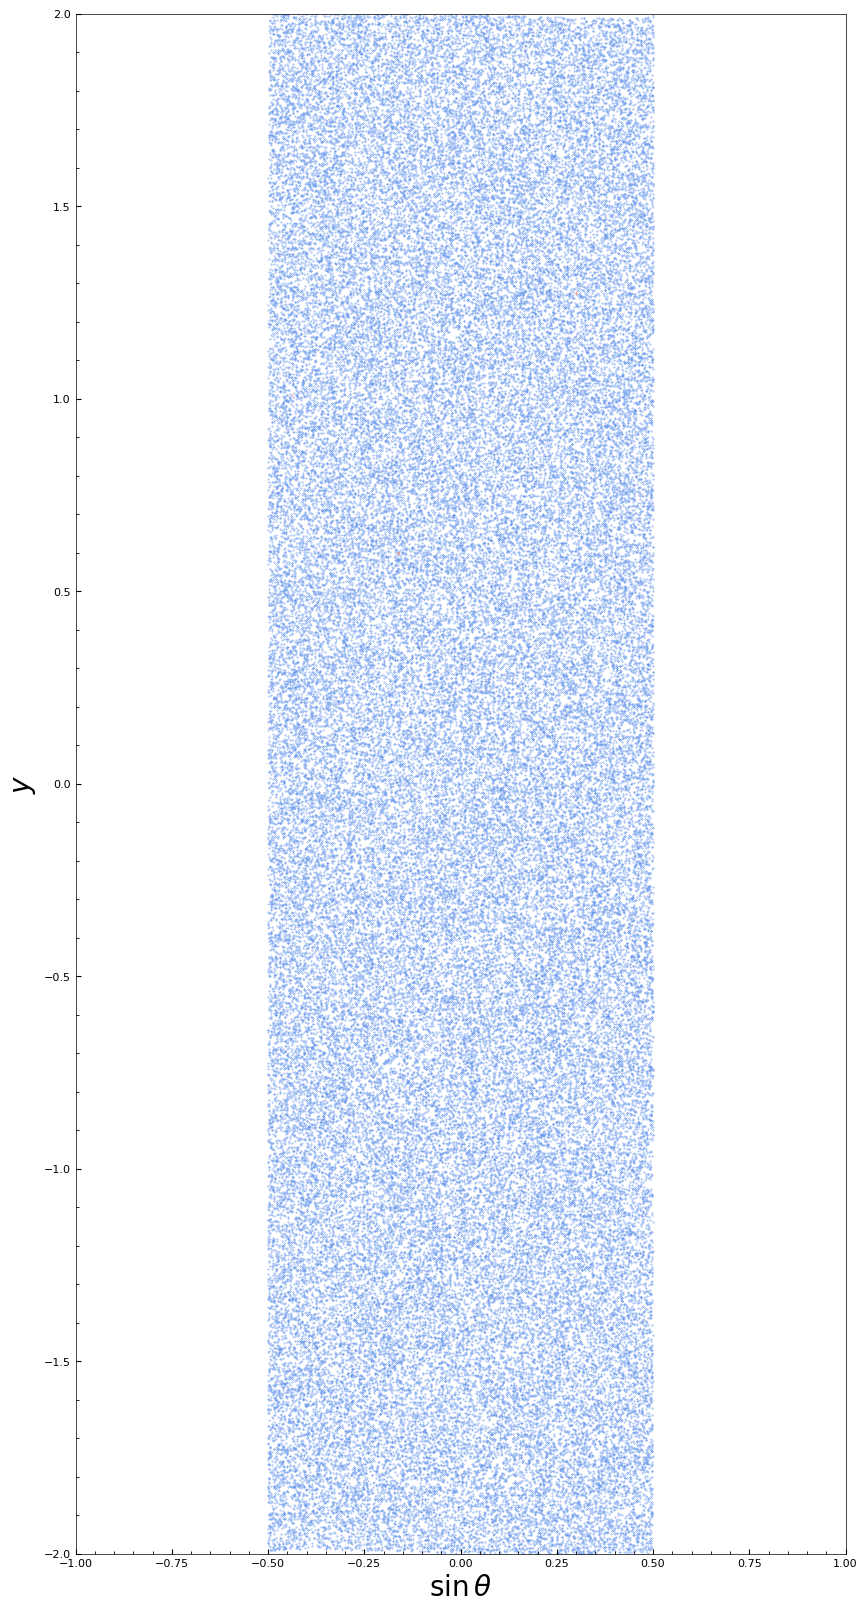

In [49]:
phase2mc = np.loadtxt('data2mc/phase.csv', delimiter = ',')
phasepara = np.loadtxt('datapara/phase.csv', delimiter = ',')
fig, ax = plt.subplots(1, figsize = (10, 20))
ax.scatter(phase2mc[:, 0], phase2mc[:, 1] / hl, s = 0.1, c = 'cornflowerblue')
ax.scatter(phasepara[:, 0], phasepara[:, 1] / hl, s = 0.1, c = 'salmon')

ax.minorticks_on() 
ax.tick_params(axis = 'x', which = 'both', direction = 'in', bottom = True, top = False, labelsize = 8)
ax.tick_params(axis = 'y', which = 'both', direction = 'in', left = True, right = False, labelsize = 8)

vert = 2
ax.spines['left'].set_position(('data', -1))
ax.spines['left'].set_bounds((-vert, vert))
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_position(('data', -vert))
ax.spines['bottom'].set_bounds((-1, 1))
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['right'].set_position(('data', 1))
ax.spines['right'].set_bounds((-vert, vert))
ax.spines['right'].set_linewidth(0.5)
ax.spines['top'].set_position(('data', vert))
ax.spines['top'].set_bounds((-1, 1))
ax.spines['top'].set_linewidth(0.5)

ax.set_xlabel(r"$\sin\theta$", size = 20)
ax.set_ylabel(r"$y$", size = 20)
ax.axis('equal')
ax.set_xlim(-1, 1)
ax.set_ylim(-vert, vert)
plt.show()

# Hits

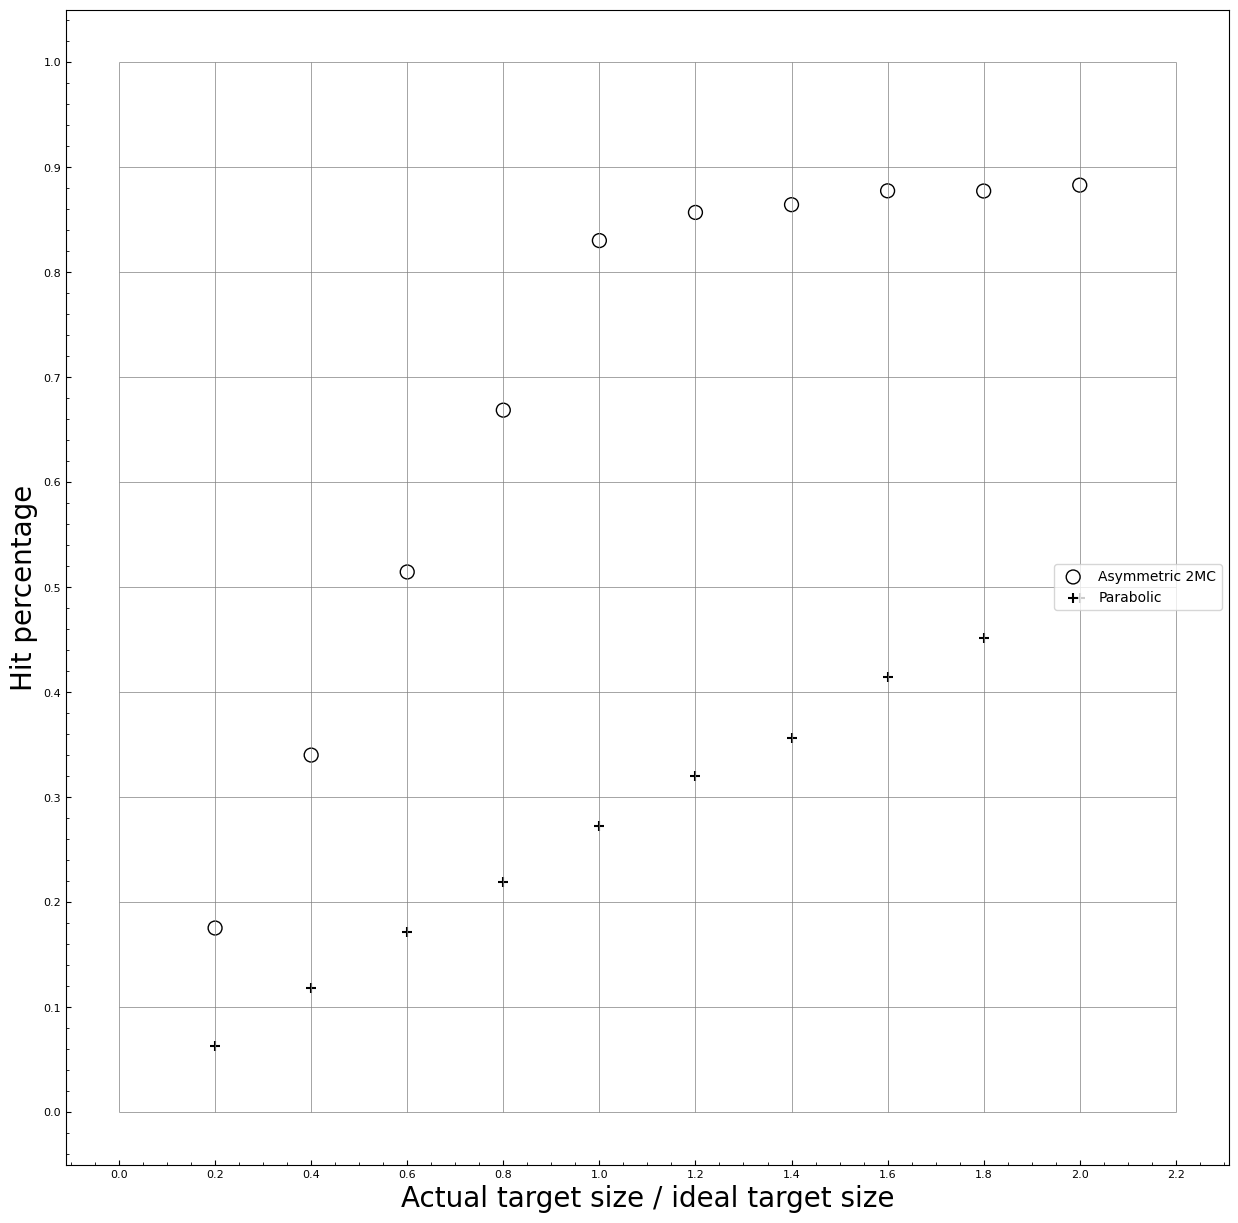

In [50]:
fig, ax = plt.subplots(1, figsize = (15, 15))
ax.locator_params(axis = 'x', nbins = 20)
ax.locator_params(axis = 'y', nbins = 20)
ax.minorticks_on() 
ax.tick_params(axis = 'x', which = 'both', direction = 'in', bottom = True, top = False, labelsize = 8)
ax.tick_params(axis = 'y', which = 'both', direction = 'in', left = True, right = False, labelsize = 8)

hit2mcasymm = np.loadtxt('data2mc/hits.csv', delimiter = ',')
# hit2mcsymm = np.loadtxt('data2mc/hits.csv', delimiter = ',')
hitpara = np.loadtxt('datapara/hits.csv', delimiter = ',')
ax.scatter(hit2mcasymm[:, 0], hit2mcasymm[:, 1], marker = 'o', s = 100, facecolors = 'none', edgecolors = (0, 0, 0), label = "Asymmetric 2MC")
# ax.scatter(hit2mcsymm[:, 0], hit2mcsymm[:, 1], marker = 's', s = 25, facecolors = 'none', color = (0, 0, 0), label = "Symmetric 2MC")
ax.scatter(hitpara[:, 0], hitpara[:, 1], marker = '+', s = 50, color = (0, 0, 0), label = "Parabolic")

ax.hlines(y = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], xmin = 0, xmax = hitpara[-1, 0] + hitpara[0, 0], linewidth = 0.5, color = 'grey')
ax.vlines(x = [0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2], ymin = 0, ymax = 1, linewidth = 0.5, color = 'grey')
ax.set_xlabel("Actual target size / ideal target size", size = 20)
ax.set_ylabel("Hit percentage", size = 20)
ax.legend(loc = "center right")
plt.show()